# Usage walkthrough

Minimal, copy-pasteable examples for every `generate_*_dataset` function in
`data_generator_funs.dataset`, plus saving and the diagnostic plots in `utils.plotting`.

- For a deeper look at *what* the data looks like and *why*, see `parameter_data_relationships.ipynb`.
- For `polynomial.py`'s internals see `polynomial_walkthrough.ipynb`.

Every `generate_*_dataset` function returns a dict with (at least):
- `X`, `Y` -- the training ensemble (`n_samples` rows), noise-free: `Y` is exactly the
  generating process applied to `X`.
- `x_true`, `y_true` -- one extra sampled row, held out of the ensemble. `y_true` is the
  generating process applied to `x_true`, but *with* observation noise/structural bias added --
  the single "real" observation a calibration exercise tries to match, using only the
  noise-free `X`/`Y` ensemble to fit a model.
- `coefficients`, `paras_to_vary`/`outputs_to_vary` (which params/outputs were marked
  "sensitive"), `structural_bias` (the bias baked into `y_true`), and `metadata`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np

from data_generator_funs.dataset import (
    generate_linear_dataset, generate_polynomial_dataset, generate_exponential_dataset,
    generate_linear_ode_dataset, generate_polynomial_ode_dataset, generate_lorenz96_dataset,
    generate_structural_regime_dataset,
    save_dataset_netcdf, default_nc_filename,
)
from utils.plotting import (
    plot_correlation, plot_data_overview, plot_scatter_examples, plot_trajectories,
    plot_regime_residuals, plot_generator_spectrum,
)

def shapes(dataset):
    return {k: v.shape for k, v in dataset.items() if hasattr(v, "shape")}
import xarray as xr

## 1. Linear -- `y = X @ B`

`structure` is `"full"` (dense), `"diag"` (banded, near-independent outputs), or `"triu"`
(one-directional sparsity mask). Sensitivity (`n_sensitive_para`/`n_sensitive_output` +
`sensitivity_multiplier`) goes inside `structure_kwargs`.

In [2]:
lin = generate_linear_dataset(
    n_samples=300, n_params=20, n_outputs=10, structure="full",
    structure_kwargs=dict(n_sensitive_para=3, n_sensitive_output=3, sensitivity_multiplier=3.0),
    noise_std=0.2, structural_idx=[0], structural_error_level=0.5, seed=1,
)
shapes(lin)

{'X': (300, 20),
 'Y': (300, 10),
 'x_true': (20,),
 'y_true': (10,),
 'paras_to_vary': (3,),
 'outputs_to_vary': (3,),
 'structural_bias': (10,)}

## 2. Polynomial -- quadratic (`degree=2`) / cubic (`degree=3`)

`n_pairs`/`n_sensitive_pairs` (and `n_triplets`/`n_sensitive_triplets` at `degree=3`) control how
many parameter pairs/triplets interact multiplicatively.

In [3]:
poly2 = generate_polynomial_dataset(
    n_samples=300, n_params=20, n_outputs=10, degree=2,
    n_sensitive_para=4, sensitivity_multiplier=3.0, n_pairs=8, n_sensitive_pairs=3,
    noise_std=0.2, structural_idx=[0], structural_error_level=0.5, seed=1,
)

poly3 = generate_polynomial_dataset(
    n_samples=300, n_params=20, n_outputs=10, degree=3,
    n_sensitive_para=4, sensitivity_multiplier=3.0, n_pairs=8, n_sensitive_pairs=3,
    n_triplets=4, n_sensitive_triplets=1,
    noise_std=0.2, structural_idx=[0], structural_error_level=0.5, seed=1,
)
shapes(poly2), shapes(poly3)

({'X': (300, 20),
  'Y': (300, 10),
  'x_true': (20,),
  'y_true': (10,),
  'paras_to_vary': (4,),
  'outputs_to_vary': (0,),
  'structural_bias': (10,),
  'pairs': (11, 2),
  'triplets': (0, 3)},
 {'X': (300, 20),
  'Y': (300, 10),
  'x_true': (20,),
  'y_true': (10,),
  'paras_to_vary': (4,),
  'outputs_to_vary': (0,),
  'structural_bias': (10,),
  'pairs': (11, 2),
  'triplets': (5, 3)})

## 3. Exponential -- `y = exp(X @ B)`

Same `structure=`/`structure_kwargs` interface as linear; `scale` (inside `structure_kwargs`)
shrinks the coefficients since summing many N(0,1) terms and exponentiating overflows quickly.

In [4]:
expo = generate_exponential_dataset(
    n_samples=300, n_params=15, n_outputs=8, structure="full",
    structure_kwargs=dict(n_sensitive_para=3, n_sensitive_output=3, scale=0.3),
    noise_std=0.1, seed=1,
)
shapes(expo)

{'X': (300, 15),
 'Y': (300, 8),
 'x_true': (15,),
 'y_true': (8,),
 'paras_to_vary': (3,),
 'outputs_to_vary': (3,),
 'structural_bias': (8,)}

## 4. Linear ODE -- `dx/dt = A x`

`n_states` replaces `n_params`/`n_outputs` (the dynamics matrix is square: state *k*'s derivative
can depend on any other state). `t_eval` is the set of observed times (`t_eval[0]` is treated as
the initial time, where `X` -- the sampled initial conditions -- lives); `n_outputs` is then
`n_states * len(t_eval)`, not chosen directly. `coefficient_scale` keeps the matrix well-scaled for
integration.

{'X': (200, 6), 'Y': (200, 60), 'x_true': (6,), 'y_true': (60,), 'paras_to_vary': (2,), 'outputs_to_vary': (20,), 'structural_bias': (60,)}


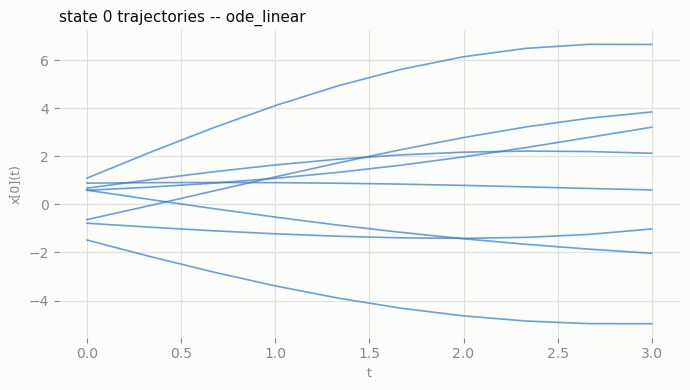

In [5]:
t_eval = np.linspace(0, 3, 10)
lin_ode = generate_linear_ode_dataset(
    n_samples=200, n_states=6, t_eval=t_eval, structure="full",
    n_sensitive_para=2, coefficient_scale=0.4,
    noise_std=0.05, seed=1,
)
print(shapes(lin_ode))
plot_trajectories(lin_ode, state_idx=0, seed=0)

## 5. Polynomial ODE -- quadratic/cubic dynamics (`degree=2/3`)

Same `n_pairs`/`n_sensitive_pairs` interaction knobs as the static polynomial generator, but now in
the right-hand side of the ODE -- with the right pair structure this reproduces Lotka-Volterra-style
predator/prey dynamics. Keep `coefficient_scale` small (quadratic/cubic feedback blows up in finite
time otherwise); if you see a `RuntimeError` from integration, lower it further or shorten `t_eval`.

{'X': (150, 4), 'Y': (150, 40), 'x_true': (4,), 'y_true': (40,), 'paras_to_vary': (2,), 'outputs_to_vary': (20,), 'structural_bias': (40,), 'pairs': (4, 2), 'triplets': (0, 3)}


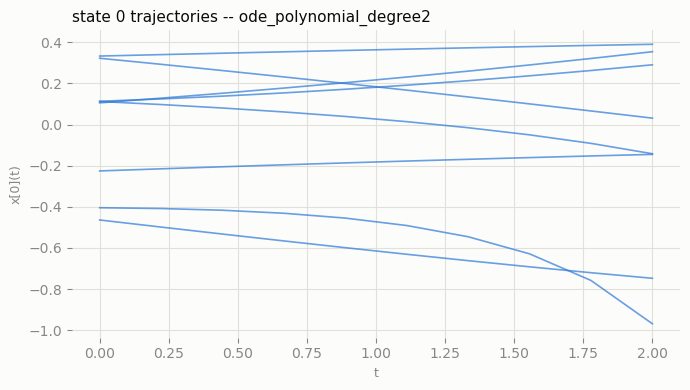

In [6]:
poly_ode = generate_polynomial_ode_dataset(
    n_samples=150, n_states=4, t_eval=np.linspace(0, 2, 10), degree=2, ic_scale=0.4,
    n_sensitive_para=2, n_pairs=3, n_sensitive_pairs=1, coefficient_scale=0.08, seed=2,
)
print(shapes(poly_ode))
plot_trajectories(poly_ode, state_idx=0, seed=0)

## 6. Lorenz-96 -- fixed chaotic coupling

No `structure=` choice -- the coupling pattern is the model. The tunable "coefficients" are the
per-state forcing (`F`, optionally amplified on `n_sensitive_para` states).

{'X': (150, 20), 'Y': (150, 600), 'x_true': (20,), 'y_true': (600,), 'paras_to_vary': (3,), 'outputs_to_vary': (90,), 'structural_bias': (600,)}


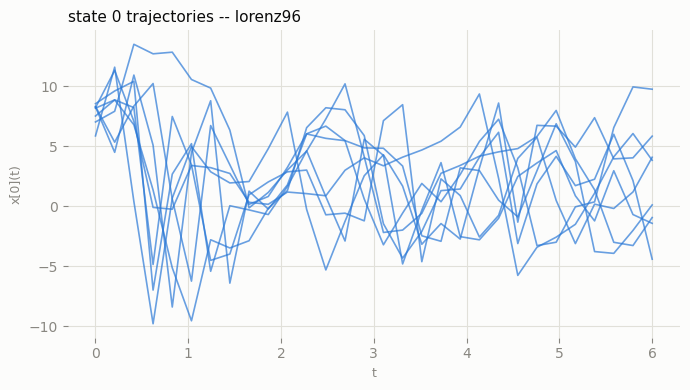

In [7]:
lz96 = generate_lorenz96_dataset(
    n_samples=150, n_states=20, t_eval=np.linspace(0, 6, 30), F=8.0,
    n_sensitive_para=3, sensitivity_multiplier=1.4, seed=3,
)
print(shapes(lz96))
plot_trajectories(lz96, state_idx=0, seed=0)

## 7. Structural regime error -- two parameter sets pooled into one dataset

Wraps *any* `generate_*_dataset` function: generates two independent datasets (`kwargs_1`/
`kwargs_2`, same dimensions) and pools their rows, shuffled together, with a `regime_label` (0/1)
kept only for diagnostics. No single coefficient set explains the pooled `Y` -- this is model-form
error, not noise.

{'X': (400, 15), 'Y': (400, 6), 'regime_label': (400,), 'paras_to_vary': (0,), 'outputs_to_vary': (0,)} regime counts: [260 140]


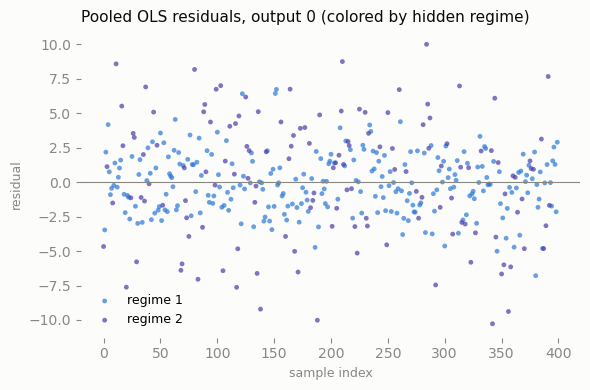

array([-4.67087359e+00, -3.47114617e+00,  2.17329995e+00,  1.12106909e+00,
        4.17084966e+00,  7.44962205e-01, -9.09218564e-01, -4.51416766e-01,
       -1.51426940e+00, -2.36584413e-01,  1.38363097e+00,  8.57519389e+00,
       -3.68711070e-01,  3.53450863e-01,  1.02033480e+00,  1.59811659e+00,
        5.51446538e+00,  2.63652800e+00, -8.81618613e-01, -2.21308459e+00,
       -7.61838203e+00, -9.69942679e-01, -1.10134698e+00, -2.67477014e+00,
       -1.13983384e+00,  1.85879444e+00,  3.53323125e+00,  3.23983673e+00,
       -1.75042883e+00, -5.78060707e+00, -2.99545094e+00,  5.52670863e-01,
        1.63117307e+00, -1.11477540e+00, -2.92080904e+00,  2.00031536e+00,
       -1.37404901e+00,  6.90203550e+00,  1.11867267e-01,  2.48537198e+00,
       -1.27443749e-01,  6.40241843e-01, -2.72609658e+00,  2.92204730e+00,
        5.07783729e+00, -2.25044656e+00,  1.02681393e+00,  2.67406090e+00,
       -2.03382085e+00, -1.77402543e+00,  3.55956291e+00, -2.78982700e+00,
       -1.67905926e+00,  

In [8]:
regime_ds = generate_structural_regime_dataset(
    generate_linear_dataset, n_samples=400, regime_fraction=0.35,
    kwargs_1=dict(n_params=15, n_outputs=6, structure="full", noise_std=0.1),
    kwargs_2=dict(n_params=15, n_outputs=6, structure="full", noise_std=0.1),
    seed=42,
)
print(shapes(regime_ds), "regime counts:", np.bincount(regime_ds["regime_label"]))
plot_regime_residuals(regime_ds, output_idx=0)

## 8. Save to NetCDF

Every dataset dict (including nested `coefficients`/`x_true`/`y_true` dicts from a
structural-regime dataset) writes to one self-documenting NetCDF file via
`save_dataset_netcdf`/`nc_path=...`: every variable gets a `description` attribute, and the
run's metadata becomes global attributes. `default_nc_filename(dataset)` builds a sensible
filename (model/structure/sizes/seed) if you don't want to name it by hand.

In [9]:
nc_path = default_nc_filename(lin_ode)
print("writing:", nc_path)
save_dataset_netcdf(lin_ode, nc_path)

ds = xr.open_dataset(nc_path)
ds

writing: ode_linear_full_n200-s6-t10_seed1.nc


<xarray.Dataset> Size: 204kB
Dimensions:          (sample: 200, input_feature: 6, output_feature: 60,
                      time: 10, state: 6, coefficients__A_col: 6,
                      paras_to_vary_index: 2, outputs_to_vary_index: 20)
Coordinates:
  * time             (time) float64 80B 0.0 0.3333 0.6667 ... 2.333 2.667 3.0
Dimensions without coordinates: sample, input_feature, output_feature, state,
                                coefficients__A_col, paras_to_vary_index,
                                outputs_to_vary_index
Data variables:
    X                (sample, input_feature) float64 10kB ...
    Y                (sample, output_feature) float64 96kB ...
    Y_by_time        (sample, time, state) float64 96kB ...
    y_true_by_time   (time, state) float64 480B ...
    x_true           (input_feature) float64 48B ...
    y_true           (output_feature) float64 480B ...
    coefficients__A  (input_feature, coefficients__A_col) float64 288B ...
    paras_to_vary    (paras_to_vary_index) int64 16B ...
    outputs_to_vary  (outputs_to_vary_index) int64 160B ...
    structural_bias  (output_feature) float64 480B ...
Attributes: (12/15)
    summary:                 Synthetic parameter-estimation dataset generated...
    model:                   ode_linear
    structure:               full
    n_samples:               200
    n_params:                6
    n_outputs:               60
    ...                      ...
    seed:                    1
    n_states:                6
    t_eval:                  [0.         0.33333333 0.66666667 1.         1.3...
    coefficient_scale:       0.4
    ic_scale:                1.0
    metadata_json:           {"model": "ode_linear", "structure": "full", "n_...

In [10]:
# ODE/Lorenz-96 datasets also get a (sample, time, state) view of Y, and a (time, state)
# view of y_true, with a real time coordinate -- alongside the flat (sample/plain,
# output_feature) arrays every family has:
print(ds["y_true_by_time"].attrs["description"])
print("time:", ds["time"].values)
print("Y matches:", np.allclose(ds["Y"].values, lin_ode["Y"]))
print("y_true matches:", np.allclose(ds["y_true"].values, lin_ode["y_true"]))
ds.close()

The generating process applied to x_true, with observation noise (noise_std) and, on structural_idx outputs, a constant structural bias (structural_error_level) added -- the single real-world-like observation a calibration exercise tries to match. Not part of the training ensemble. Reshaped to (time, state).
time: [0.         0.33333333 0.66666667 1.         1.33333333 1.66666667
 2.         2.33333333 2.66666667 3.        ]
Y matches: True
y_true matches: True


In [11]:
# nested coefficients (regime_1/regime_2) flatten to e.g. "coefficients__regime_1__coefficients":
regime_nc_path = default_nc_filename(regime_ds)
print("writing:", regime_nc_path)
save_dataset_netcdf(regime_ds, regime_nc_path)
list(xr.open_dataset(regime_nc_path).data_vars)

writing: generate_linear_dataset_regime0.35_n400_seed42.nc


['X',
 'Y',
 'x_true__regime_1',
 'x_true__regime_2',
 'y_true__regime_1',
 'y_true__regime_2',
 'regime_label',
 'coefficients__regime_1__coefficients',
 'coefficients__regime_2__coefficients',
 'paras_to_vary',
 'outputs_to_vary']

## Diagnostic plots cheat-sheet

All take a dataset dict (as returned by any `generate_*_dataset` function) unless noted.

| function | shows |
|---|---|
| `plot_correlation(X, Y, sensitive_param_idx=..., sensitive_output_idx=...)` | correlation heatmap between every X column and every Y column |
| `plot_data_overview(dataset)` | per-output bars: coefficient sparsity, nonlinearity, interaction strength |
| `plot_scatter_examples(dataset, n_examples=3)` | Y_true vs. its most-correlated X column, for a few outputs |
| `plot_trajectories(dataset, state_idx=0, n_examples=8)` | ODE/Lorenz-96 only -- a state's trajectory over `t_eval` for a few samples |
| `plot_regime_residuals(dataset, output_idx=0)` | structural-regime datasets only -- pooled-OLS residuals colored by hidden regime |
| `plot_generator_spectrum({label: dataset, ...})` | compares several datasets' mean nonlinearity/interaction side by side |
